In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [43]:
#load data from CSV with unicode encoding
df = pd.read_csv("data/raw/train_data.csv", sep=',', encoding='utf-8')

C:\Users\hempe\AppData\Local\Temp\ipykernel_30560\2260802705.py:2: DtypeWarning: Columns (0: Kd (nM), 1: EC50 (nM), 2: koff (s-1), 3: UniProt (TrEMBL) Submitted Name of Target Chain 2, 4: UniProt (TrEMBL) Entry Name of Target Chain 2, 5: UniProt (TrEMBL) Primary ID of Target Chain 2, 6: UniProt (TrEMBL) Secondary ID(s) of Target Chain 2, 7: BindingDB Target Chain Sequence 3, 8: PDB ID(s) of Target Chain 3, 9: UniProt (SwissProt) Recommended Name of Target Chain 3, 10: UniProt (SwissProt) Entry Name of Target Chain 3, 11: UniProt (SwissProt) Primary ID of Target Chain 3, 12: UniProt (SwissProt) Secondary ID(s) of Target Chain 3, 13: UniProt (TrEMBL) Submitted Name of Target Chain 3, 14: UniProt (TrEMBL) Entry Name of Target Chain 3, 15: UniProt (TrEMBL) Primary ID of Target Chain 3, 16: UniProt (TrEMBL) Secondary ID(s) of Target Chain 3, 17: BindingDB Target Chain Sequence 4, 18: PDB ID(s) of Target Chain 4, 19: UniProt (SwissProt) Recommended Name of Target Chain 4, 20: UniProt (SwissP

In [44]:
#Select relevant feaures
df=df[['Ligand SMILES', 'BindingDB Target Chain Sequence 1', 'IC50 (nM)']]
df.head()

,Ligand SMILES,BindingDB Target Chain Sequence 1,IC50 (nM)
0,O=C1N(CN2CCOCC2)c2ccccc2C1=O,MWLCALALASLAACTAWGHPSAPPVVDTVHGKVLGKFVSLEGFAQPVAVFLGVPFAKPPLGSLRFAPPQPAESWSHVKNTTSYPPMCSQDAVSGHMLSELFTNRKENIPLKFSEDCLYLNIYTPADLTKRGRLPVMVWIHGGGLMVGGASTYDGLALSAHENVVVVTIQYRLGIWGFFSTGDEHSRGNWGHLDQVAALRWVQDNIANFGGDPGSVTIFGESAGGQSVSILLLSPLTKNLFHRAISESGVALLSSLFRKNTKSLAEKIAIEAGCKTTTSAVMVHCLRQKTEEELMEVTLKMKFMALDLVGDPKENTAFLTTVIDGVLLPKAPAEILAEKKYNMLPYMVGINQQEFGWIIPMQMLGYPLSEGKLDQKTATELLWKSYPIVNVSKELTPVATEKYLGGTDDPVKKKDLFLDMLADLLFGVPSVNVARHHRDAGAPTYMYEYRYRPSFSSDMRPKTVIGDHGDEIFSVLGAPFLKEGATEEEIKLSKMVMKYWANFARNGNPNGEGLPQWPAYDYKEGYLQIGATTQAAQKLKDKEVAFWTELWAKEAARPRETEHIEL,NaN
1,CCc1cn2CCS(=O)(=O)Oc3cc(cc1c23)C(=O)N[C@@H](Cc1ccccc1)[C@H](O)CNC1CCOCC1 |r|,MGALARALLLPLLAQWLLRAAPELAPAPFTLPLRVAAATNRVVAPTPGPGTPAERHADGLALALEPALASPAGAANFLAMVDNLQGDSGRGYYLEMLIGTPPQKLQILVDTGSSNFAVAGTPHSYIDTYFDTERSSTYRSKGFDVTVKYTQGSWTGFVGEDLVTIPKGFNTSFLVNIATIFESENFFLPGIKWNGILGLAYATLAKPSSSLETFFDSLVTQANIPNVFSMQMCGAGLPVAGSGTNGGSLVLGGIEPSLYKGDIWYTPIKEEWYYQIEILKLEIGGQSLNLDCREYNADKAIVDSGTTLLRLPQKVFDAVVEAVARASLIPEFSDGFWTGSQLACWTNSETPWSYFPKISIYLRDENSSRSFRITILPQLYIQPMMGAGLNYECYRFGISPSTNALVIGATVMEGFYVIFDRAQKRVGFAASPCAEIAGAAVSEISGPFSTEDVASNCVPAQSLSEPILWIVSYALMSVCGAILLVLIVLLLLPFRCQRRPRDPEVVNDESSLVRHRWK,450
2,Clc1cccc(Nc2ncnc3n[nH]c(NCc4ccccc4)c23)c1,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCEVVLGNLEITYVQRNYDLSFLKTIQEVAGYVLIALNTVERIPLENLQIIRGNMYYENSYALAVLSNYDANKTGLKELPMRNLQEILHGAVRFSNNPALCNVESIQWRDIVSSDFLSNMSMDFQNHLGSCQKCDPSCPNGSCWGAGEENCQKLTKIICAQQCSGRCRGKSPSDCCHNQCAAGCTGPRESDCLVCRKFRDEATCKDTCPPLMLYNPTTYQMDVNPEGKYSFGATCVKKCPRNYVVTDHGSCVRACGADSYEMEEDGVRKCKKCEGPCRKVCNGIGIGEFKDSLSINATNIKHFKNCTSISGDLHILPVAFRGDSFTHTPPLDPQELDILKTVKEITGFLLIQAWPENRTDLHAFENLEIIRGRTKQHGQFSLAVVSLNITSLGLRSLKEISDGDVIISGNKNLCYANTINWKKLFGTSGQKTKIISNRGENSCKATGQVCHALCSPEGCWGPEPRDCVSCRNVSRGRECVDKCNLLEGEPREFVENSECIQCHPECLPQAMNITCTGRGPDNCIQCAHYIDGPHCVKTCPAGVMGENNTLVWKYADAGHVCHLCHPNCTYGCTGPGLEGCPTNGPKIPSIATGMVGALLLLLVVALGIGLFMRRRHIVRKRTLRRLLQERELVEPLTPSGEAPNQALLRILKETEFKKIKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMDEEDMDDVVDADEYLIPQQGFFSSPSTSRTPLLSSLSATSNNSTVACIDRNGLQSCPIKEDSFLQRYSSDPTGALTEDSIDDTFLPVPEYINQSVPKRPAGSVQNPVYHNQPLNPAPSRDPHYQDPHSTAVGNPEYLNTVQPTCVNSTFDSPAHWAQKGSHQISLDNPDYQQDFFPKEAKPNGIFKGSTAENAEYLRVAPQSSEFIGA,7
3,CC1CCCCCCCC(=O)Cc2c(Cl)c(O)cc(O)c2C(=O)O1,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIRYKSLSDPKQLETEPDLFIRITPKPEQKVLEIRDSGIGMTKAELINNLGTIAKSGTKAFMEALSAGADVSMIGQFGVGFYSLFLVADRVQVISKSNDDEQYIWESNAGGSFTVTLDEVNERIGRGTILRLFLKDDQLEYLEEKRIKEVIKRHSEFVAYPIQLVVTKEVEKEVPIPEEEKKDEEKKDEEKKDEDDKKPKLEEVDEEEEKKPKTKKVKEEVQEIEELNKTKPLWTRNPSDITQEEYNAFYKSISNDWEDPLYVKHFSVEGQLEFRAILFIPKRAPFDLFESKKKKNNIKLYVRRVFITDEAEDLIPEWLSFVKGVVDSEDLPLNLSREMLQQNKIMKVIRKNIVKKLIEAFNEIAEDSEQFEKFYSAFSKNIKLGVHEDTQNRAALAKLLRYNSTKSVDELTSLTDYVTRMPEHQKNIYYITGESLKAVEKSPFLDALKAKNFEVLFLTDPIDEYAFTQLKEFEGKTLVDITKDFELEETDEEKAEREKEIKEYEPLTKALKEILGDQVEKVVVSYKLLDAPAAIRTGQFGWSANMERIMKAQALRDSSMSSYMSSKKTFEISPKSPIIKELKKRVDEGGAQDKTVKDLTKLLYETALLTSGFSLDEPTSFASRINRLISLGLNIDEDEETETAPEASTAAPVEEVPADTEMEEVD,1.29e+3
4,COc1cc(ccc1N)-c1ccc2c(n[nH]c2c1)-c1nc2c(cccc2[nH]1)N1CCN(C)CC1,MPSRTGPKMEGSGGRVRLKAHYGGDIFITSVDAATTFEELCEEVRDMCRLHQQHPLTLKWVDSEGDPCTVSSQMELEEAFRLARQCRDEGLIIHVFPSTPEQPGLPCPGEDKSIYRRGARRWRKLYRANGHLFQAKRFNRRAYCGQCSERIWGLARQGYRCINCKLLVHKRCHGLVPLTCRKHMDSVMPSQEPPVDDKNEDADLPSEETDGIAYISSSRKHDSIKDDSEDLKPVIDGMDGIKISQGLGLQDFDLIRVIGRGSYAKVLLVRLKKNDQIYAMKVVKKELVHDDEDIDWVQTEKHVFEQASSNPFLVGLHSCFQTTSRLFLVIEYVNGGDLMFHMQRQRKLPEEHARFYAAEICIALNFLHERGIIYRDLKLDNVLLDADGHIKLTDYGMCKEGLGPGDTTSTFCGTPNYIAPEILRGEEYGFSVDWWALGVLMFEMMAGRSPFDIITDNPDMNTEDYLFQVILEKPIRIPRFLSVKASHVLKGFLNKDPKERLGCRPQTGFSDIKSHAFFRSIDWDLLEKKQALPPFQPQITDDYGLDNFDTQFTSEPVQLTPDDEDAIKRIDQSEFEGFEYINPLLLSTEESV,51.3


In [50]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

overview = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "Missing": df.isna().sum().values
})

overview


,Column,Dtype,Missing
0,Ligand SMILES,str,1
1,BindingDB Target Chain Sequence 1,str,0
2,IC50 (nM),float64,31376


In [53]:
df["IC50 (nM)"] = pd.to_numeric(df["IC50 (nM)"], errors="coerce")
pd.set_option("display.float_format", "{:,.2f}".format)
df["IC50 (nM)"].describe()

count        43,999.00
mean         98,742.84
std       4,133,193.94
min               0.00
25%              60.00
50%             790.00
75%           8,900.00
max     459,000,000.00
Name: IC50 (nM), dtype: float64

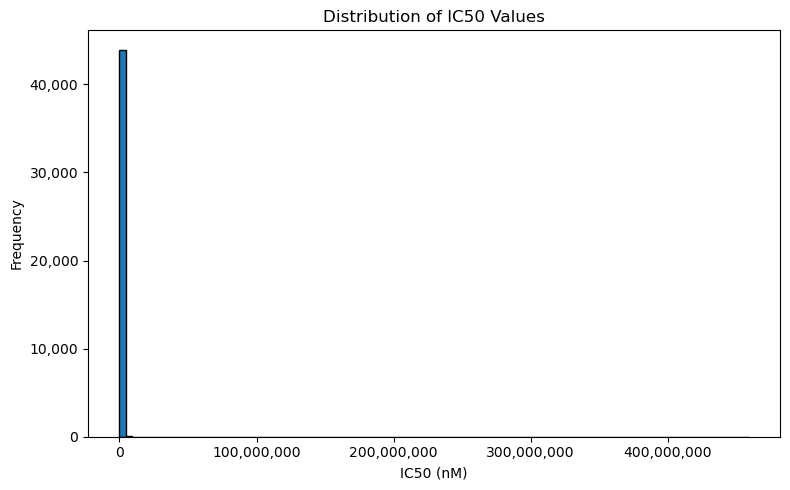

In [69]:
# Plot histogram of IC50 values
plt.figure(figsize=(8,5))
plt.hist(df["IC50 (nM)"], bins=100, edgecolor="black")

plt.xlabel("IC50 (nM)")
plt.ylabel("Frequency")
plt.title("Distribution of IC50 Values")


# Keine wissenschaftliche Schreibweise auf x- und y-Achse
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


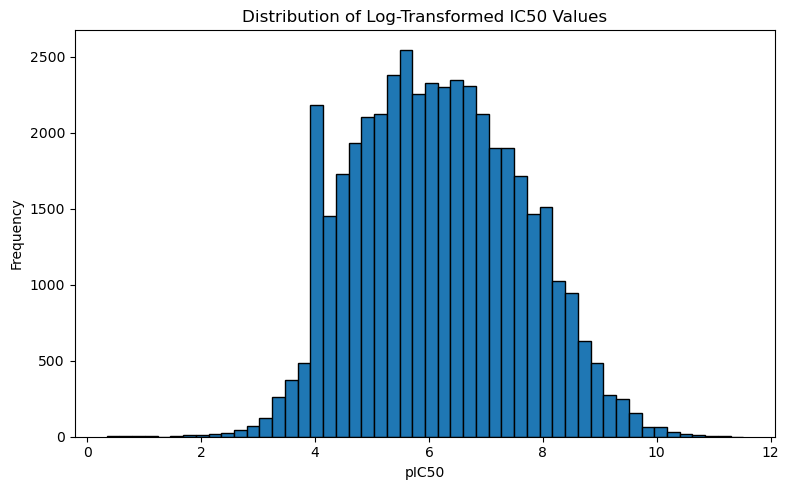

In [49]:
# Calculate pIC50 from IC50 (nM)
pic50 = -np.log10(df["IC50 (nM)"] * 1e-9)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(pic50, bins=50, edgecolor="black")

plt.xlabel("pIC50")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed IC50 Values")

plt.tight_layout()
plt.show()